In [1]:
!pip install einops -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math, warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


Saving Electric_Production.csv to Electric_Production.csv
        date    value
0 1985-01-01  72.5052
1 1985-02-01  70.6720
2 1985-03-01  62.4502
3 1985-04-01  57.4714
4 1985-05-01  55.3151

Shape: (397, 2)  |  Range: 1985-01-01 00:00:00 → 2018-01-01 00:00:00


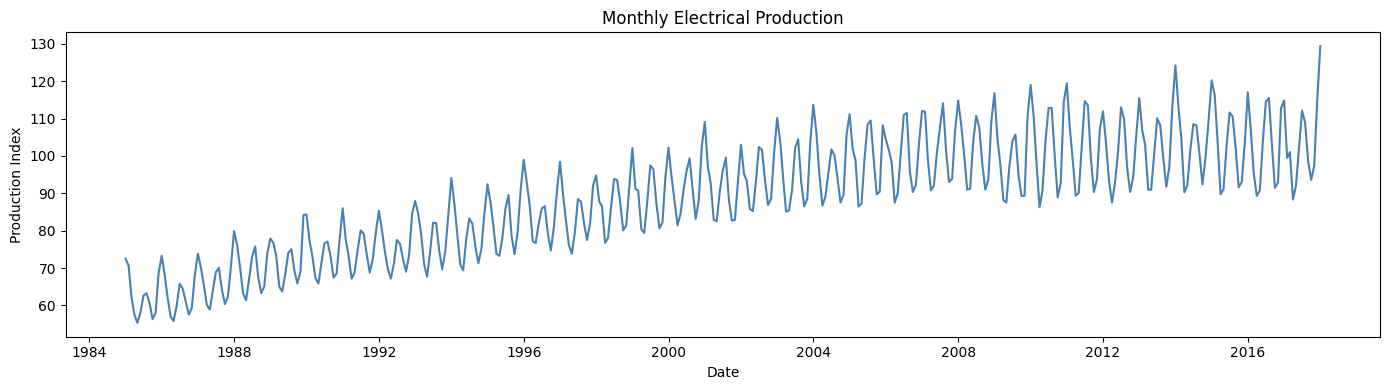

In [2]:
from google.colab import files
uploaded = files.upload()   # upload Electric_Production.csv

df = pd.read_csv("Electric_Production.csv", parse_dates=["DATE"])
df.columns = ["date", "value"]
df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print(f"\nShape: {df.shape}  |  Range: {df.date.min()} → {df.date.max()}")

plt.figure(figsize=(14, 4))
plt.plot(df.date, df.value, color="steelblue")
plt.title("Monthly Electrical Production")
plt.xlabel("Date"); plt.ylabel("Production Index")
plt.tight_layout(); plt.show()

In [3]:
SEQ_LEN    = 24   # look-back window (months)
PRED_LEN   = 1    # predict 1 step at a time
BATCH_SIZE = 32
EPOCHS     = 50
FUTURE     = 120  # 10 years = 120 months

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["value"]]).flatten()

# Train/Val/Test split (70/15/15)
n = len(scaled)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_data = scaled[:train_end]
val_data   = scaled[train_end - SEQ_LEN : val_end]
test_data  = scaled[val_end  - SEQ_LEN :]

print(f"Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")


Train: 277  Val: 84  Test: 84


In [4]:
class TSDataset(Dataset):
    def __init__(self, data, seq_len):
        self.X, self.y = [], []
        for i in range(len(data) - seq_len):
            self.X.append(data[i : i + seq_len])
            self.y.append(data[i + seq_len])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TSDataset(train_data, SEQ_LEN)
val_ds   = TSDataset(val_data,   SEQ_LEN)
test_ds  = TSDataset(test_data,  SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print("Train batches:", len(train_loader))



Train batches: 8


In [5]:
class RNNModel(nn.Module):
    def __init__(self, hidden=64, layers=2):
        super().__init__()
        self.rnn = nn.RNN(1, hidden, layers, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        x, _ = self.rnn(x.unsqueeze(-1))
        return self.fc(x[:, -1, :]).squeeze(-1)

# --- LSTM ---
class LSTMModel(nn.Module):
    def __init__(self, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        x, _ = self.lstm(x.unsqueeze(-1))
        return self.fc(x[:, -1, :]).squeeze(-1)

# --- GRU ---
class GRUModel(nn.Module):
    def __init__(self, hidden=64, layers=2):
        super().__init__()
        self.gru = nn.GRU(1, hidden, layers, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        x, _ = self.gru(x.unsqueeze(-1))
        return self.fc(x[:, -1, :]).squeeze(-1)

# --- Vision Transformer (1D patch-based) ---
class PatchEmbed(nn.Module):
    def __init__(self, seq_len, patch_size, d_model):
        super().__init__()
        self.patch_size = patch_size
        n_patches = seq_len // patch_size
        self.proj = nn.Linear(patch_size, d_model)
        self.cls  = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos  = nn.Parameter(torch.randn(1, n_patches + 1, d_model))

    def forward(self, x):                         # x: (B, L)
        B, L = x.shape
        x = x.reshape(B, L // self.patch_size, self.patch_size)
        x = self.proj(x)                          # (B, n_patches, d_model)
        cls = self.cls.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos
        return x

class ViTModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, patch_size=4, d_model=64,
                 n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.embed   = PatchEmbed(seq_len, patch_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, n_heads, dim_feedforward=128,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embed(x)
        x = self.transformer(x)
        return self.head(x[:, 0, :]).squeeze(-1)   # CLS token


In [11]:
def train_model(name, model, train_loader, val_loader, epochs=EPOCHS):
    print(f"\n{'='*50}")
    print(f"  Training {name}")
    print(f"{'='*50}")

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = nn.MSELoss()
    best_val, best_state = float("inf"), None
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- train ---
        model.train()
        t_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = criterion(pred, y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_loss += loss.item()

        # --- validate ---
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                v_loss += criterion(model(X), y).item()

        t_loss /= len(train_loader)
        v_loss /= len(val_loader)
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        scheduler.step(v_loss)

        if v_loss < best_val:
            best_val = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}]  "
                  f"Train Loss: {t_loss:.5f}  Val Loss: {v_loss:.5f}")

    model.load_state_dict(best_state)
    print(f"  Best Val Loss: {best_val:.5f}")
    return model, train_losses, val_losses


def evaluate(name, model, test_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in test_loader:
            preds.extend(model(X.to(device)).cpu().numpy())
            trues.extend(y.numpy())

    preds = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
    trues = scaler.inverse_transform(np.array(trues).reshape(-1,1)).flatten()

    mae  = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    mape = np.mean(np.abs((trues - preds) / trues)) * 100

    print(f"\n{name:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
    return preds, trues, {"MAE": mae, "RMSE": rmse, "MAPE": mape}

In [12]:
models_cfg = {
    "RNN"  : RNNModel(),
    "LSTM" : LSTMModel(),
    "GRU"  : GRUModel(),
    "ViT"  : ViTModel(),
}

trained, histories, metrics_all = {}, {}, {}

for name, model in models_cfg.items():
    m, tl, vl = train_model(name, model, train_loader, val_loader)
    trained[name]   = m
    histories[name] = (tl, vl)
    _, _, met = evaluate(name, m, test_loader)
    metrics_all[name] = met


  Training RNN
  Epoch [10/50]  Train Loss: 0.00871  Val Loss: 0.01346
  Epoch [20/50]  Train Loss: 0.00358  Val Loss: 0.00255
  Epoch [30/50]  Train Loss: 0.00297  Val Loss: 0.00233
  Epoch [40/50]  Train Loss: 0.00238  Val Loss: 0.00297
  Epoch [50/50]  Train Loss: 0.00219  Val Loss: 0.00240
  Best Val Loss: 0.00203

RNN                   MAE=3.08  RMSE=4.36  MAPE=2.89%

  Training LSTM
  Epoch [10/50]  Train Loss: 0.01527  Val Loss: 0.01817
  Epoch [20/50]  Train Loss: 0.01033  Val Loss: 0.01912
  Epoch [30/50]  Train Loss: 0.00995  Val Loss: 0.01922
  Epoch [40/50]  Train Loss: 0.00981  Val Loss: 0.01927
  Epoch [50/50]  Train Loss: 0.00957  Val Loss: 0.01884
  Best Val Loss: 0.01778

LSTM                  MAE=8.34  RMSE=10.16  MAPE=8.04%

  Training GRU
  Epoch [10/50]  Train Loss: 0.01262  Val Loss: 0.01822
  Epoch [20/50]  Train Loss: 0.00972  Val Loss: 0.01698
  Epoch [30/50]  Train Loss: 0.00929  Val Loss: 0.01586
  Epoch [40/50]  Train Loss: 0.00849  Val Loss: 0.01475
  Epoc

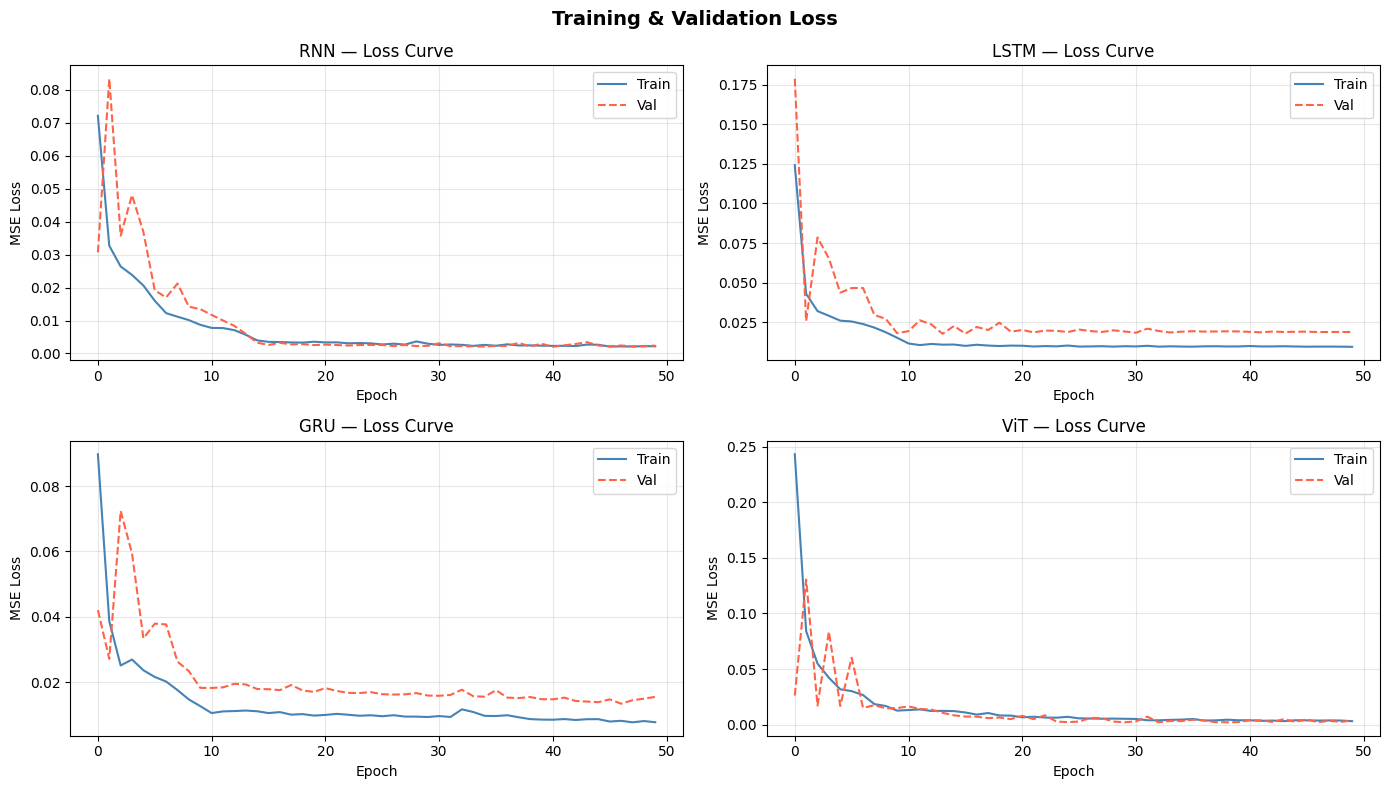

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, (tl, vl)) in zip(axes.flatten(), histories.items()):
    ax.plot(tl, label="Train", color="steelblue")
    ax.plot(vl, label="Val",   color="tomato", linestyle="--")
    ax.set_title(f"{name} — Loss Curve")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Training & Validation Loss", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("loss_curves.png", dpi=150); plt.show()

In [19]:
def forecast_future(model, last_seq, steps=120):
    model.eval()
    seq  = list(last_seq)
    preds = []
    with torch.no_grad():
        for _ in range(steps):
            x    = torch.tensor(seq[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)
            pred = model(x).item()
            preds.append(pred)
            seq.append(pred)
    return scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()


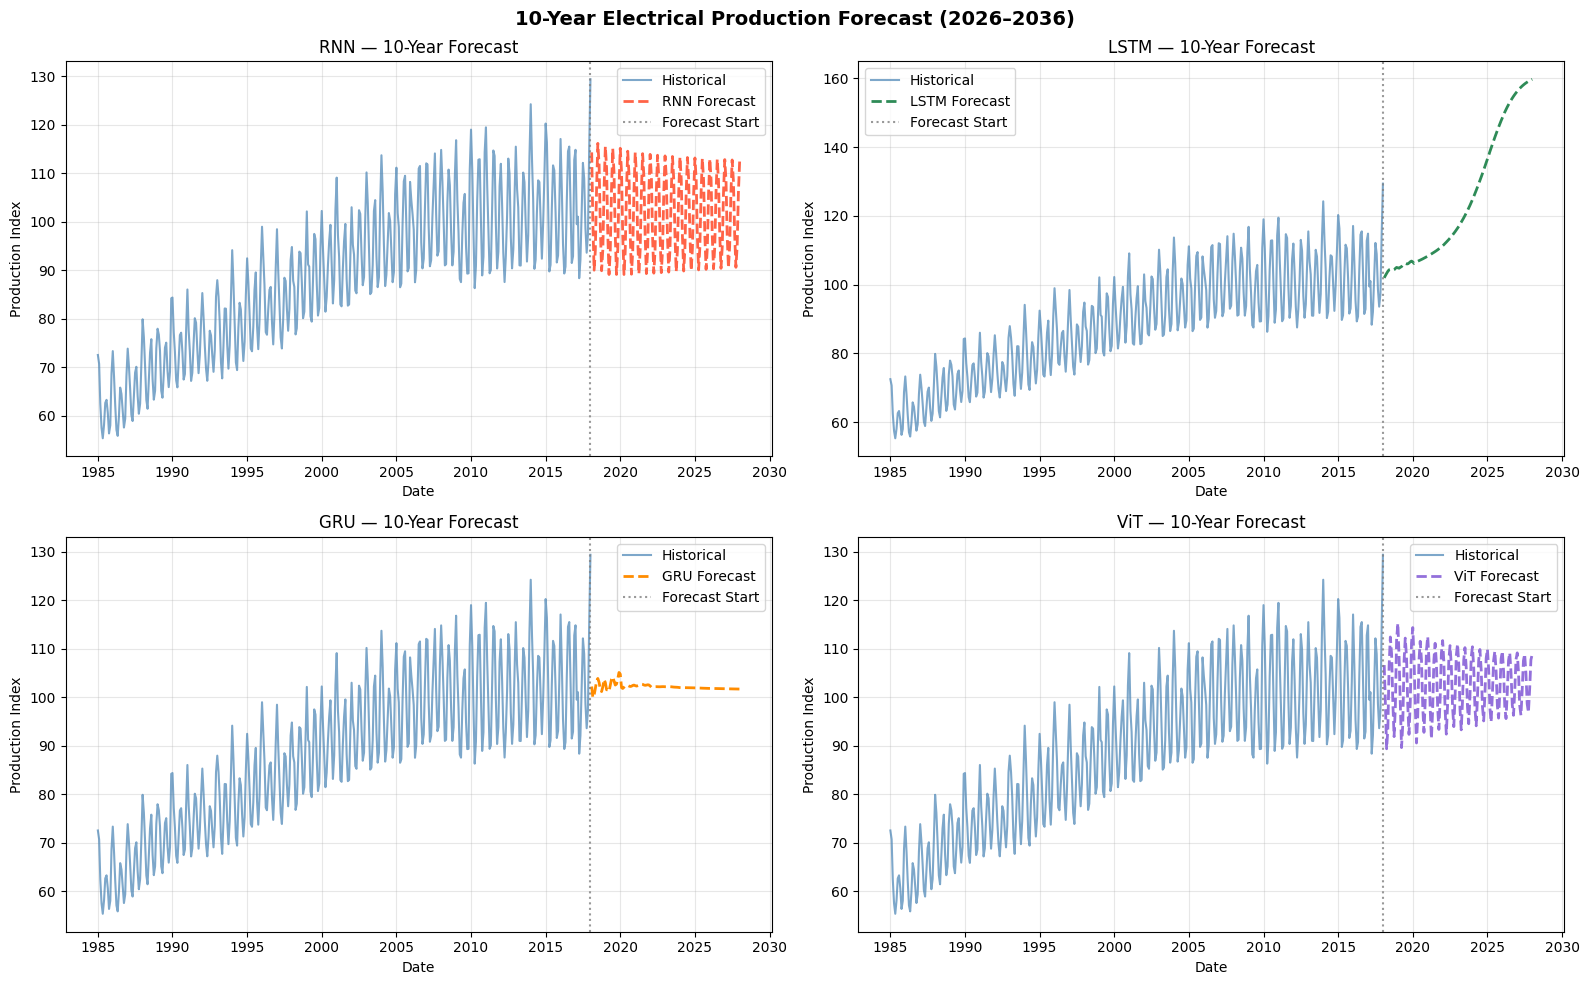

In [20]:
# Generate future dates (monthly)
last_date    = df.date.max()
future_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=FUTURE, freq="MS")

# Run forecast for all models
forecasts = {}
last_seq  = scaled[-SEQ_LEN:]

for name, model in trained.items():
    forecasts[name] = forecast_future(model, last_seq)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {"RNN": "tomato", "LSTM": "seagreen", "GRU": "darkorange", "ViT": "mediumpurple"}

for ax, name in zip(axes.flatten(), forecasts):
    ax.plot(df.date, df.value, color="steelblue", label="Historical", alpha=0.7)
    ax.plot(future_dates, forecasts[name], color=colors[name],
            linewidth=2, linestyle="--", label=f"{name} Forecast")
    ax.axvline(last_date, color="gray", linestyle=":", alpha=0.8, label="Forecast Start")
    ax.set_title(f"{name} — 10-Year Forecast")
    ax.set_xlabel("Date"); ax.set_ylabel("Production Index")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("10-Year Electrical Production Forecast (2026–2036)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("10yr_forecast.png", dpi=150); plt.show()


         MODEL COMPARISON METRICS
        MAE    RMSE   MAPE
RNN   3.077   4.358  2.892
LSTM  8.338  10.163  8.042
GRU   7.346   8.982  7.069
ViT   3.162   4.512  2.963


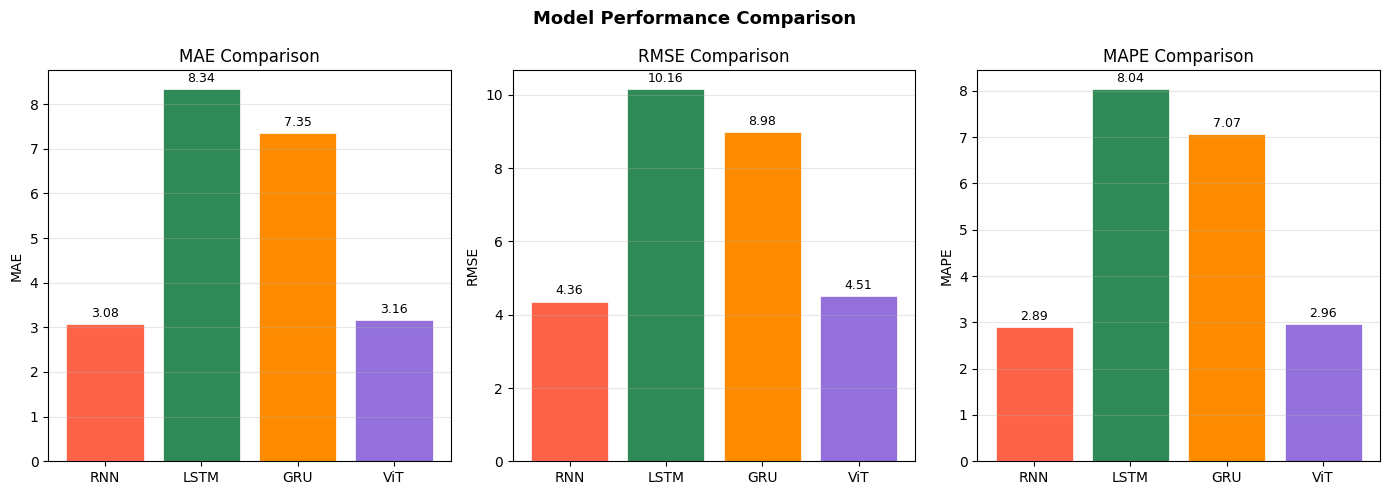


🏆 Best Model by RMSE: RNN


In [21]:
metrics_df = pd.DataFrame(metrics_all).T
print("\n" + "="*50)
print("         MODEL COMPARISON METRICS")
print("="*50)
print(metrics_df.round(3).to_string())
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    vals = [metrics_all[m][metric] for m in metrics_all]
    bars = ax.bar(list(metrics_all.keys()), vals,
                  color=list(colors.values()), edgecolor="white", linewidth=0.5)
    ax.set_title(f"{metric} Comparison"); ax.set_ylabel(metric)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("metrics_comparison.png", dpi=150); plt.show()

best_model = min(metrics_all, key=lambda m: metrics_all[m]["RMSE"])
print(f"\n Best Model by RMSE: {best_model}")